# PointNet for ModelNet40
Adapted to the ModelNet40 dataset. This notebook uses all 40 classes.

we write the dimensions as such:
- D is the amount of features (3 features: x, y, z)
- N is the amount of points per mesh
- B is the amount of batches

Among the N dimension, theres invariance by permutation because point order doesnt matter.

In [33]:
from functools import lru_cache
from pathlib import Path
import time
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from IPython.display import clear_output

In [34]:
PROJECT_ROOT = Path('/Users/elo/Coding/radar')
DATA_ROOT = PROJECT_ROOT / 'datasets' / 'ModelNet40'
CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints' / 'modelNET_pointnetV1'
SEEDS = [12] # reproduce results and check initialization sentivity
DEVICE = "mps"

MODELNET_CLASS_NAMES = (
    'airplane', 'bathtub', 'bed', 'bench', 'bookshelf', 'bottle', 'bowl', 'car', 'chair', 'cone',
    'cup', 'curtain', 'desk', 'door', 'dresser', 'flower_pot', 'glass_box', 'guitar', 'keyboard', 'lamp',
    'laptop', 'mantel', 'monitor', 'night_stand', 'person', 'piano', 'plant', 'radio', 'range_hood', 'sink',
    'sofa', 'stairs', 'stool', 'table', 'tent', 'toilet', 'tv_stand', 'vase', 'wardrobe', 'xbox')

CONFIG = {
    'feature_names': ('x', 'y', 'z'),
    'surface_points_per_model': 2048,
    'points_per_model': 1024, # the amount of points from the paper that saturates performances
    'batch_size': 64,
    'dropout_rate': 0.3,
    'smoothing': 0.1,  # label smoothing for generalization
    'training_fraction': 0.5, # to iterate faster
    'validation_fraction': 0.2, # for training stopping
    "num_epochs": 100,
    "base_lr": 1e-3,
    "min_lr": 1e-5,
    "adam_momentum": 0.9,
    "lr_decay_samples": 200000,  # reduce LR every N samples (better than epochs)
    "lr_decay_gamma": 0.7,
}

# data preparation

In [35]:
@lru_cache(maxsize=None)
def load_modelnet_file(file_path):
    "Load an OFF mesh and return normalized surface-sampled points."
    with Path(file_path).open('r') as handle:
        header = handle.readline().split()
        counts = header[1:] if len(header) > 1 and header[0] == 'OFF' else ([header[0][3:], *header[1:]] if header[0] != 'OFF' else handle.readline().split())
        vertex_count, face_count = int(counts[0]), int(counts[1])
        vertices = torch.tensor([[float(value) for value in handle.readline().split()[:3]] for _ in range(vertex_count)], dtype=torch.float32)
        triangles = []
        for _ in range(face_count):
            face = [int(value) for value in handle.readline().split()]
            triangles.extend([face[1], face[i], face[i + 1]] for i in range(2, face[0]))

    triangles = vertices[torch.tensor(triangles, dtype=torch.long)]
    vectors = triangles[:, 1:] - triangles[:, :1]
    areas = torch.cross(vectors[:, 0], vectors[:, 1], dim=1).norm(dim=1)
    valid = torch.isfinite(areas) & (areas > 0)
    triangles, areas = triangles[valid], areas[valid]
    chosen = triangles[torch.multinomial(areas, CONFIG['surface_points_per_model'], replacement=True)]
    u, v = torch.rand(CONFIG['surface_points_per_model'], 1), torch.rand(CONFIG['surface_points_per_model'], 1)
    over = (u + v).squeeze(1) > 1
    u[over], v[over] = 1 - u[over], 1 - v[over]
    points = chosen[:, 0] + u * (chosen[:, 1] - chosen[:, 0]) + v * (chosen[:, 2] - chosen[:, 0])
    points = points - points.mean(dim=0)
    points = points / torch.norm(points, dim=1).max()
    return points[:CONFIG['points_per_model']]

In [36]:
def build_sample_index(split_name):
    "Creates one sample per OFF file."
    samples = []
    for class_name in MODELNET_CLASS_NAMES:
        for file_path in sorted(DATA_ROOT.rglob(f'{class_name}/{split_name}/*.off')):
            samples.append((str(file_path), MODELNET_CLASS_NAMES.index(class_name)))
    return samples

In [37]:
@lru_cache(maxsize=None)
def validation_split(seed):
    "Split a smaller ModelNet train subset into train and validation samples."
    all_train_samples = build_sample_index('train')
    generator = torch.Generator().manual_seed(seed)
    train_samples, valid_samples = [], []
    for class_idx in range(len(MODELNET_CLASS_NAMES)):
        class_samples = [sample for sample in all_train_samples if sample[1] == class_idx]
        order = torch.randperm(len(class_samples), generator=generator).tolist()
        selected = [class_samples[idx] for idx in order[:int(len(class_samples) * CONFIG['training_fraction'])]]
        valid_count = int(len(selected) * CONFIG['validation_fraction'])
        valid_samples.extend(selected[:valid_count])
        train_samples.extend(selected[valid_count:])
    return train_samples, valid_samples

In [38]:
sample_file = next(DATA_ROOT.rglob('*.off'))
points = load_modelnet_file(str(sample_file))
print(len(points))
print(points.shape) # (points_per_model, len(feature_names))

1024
torch.Size([1024, 3])


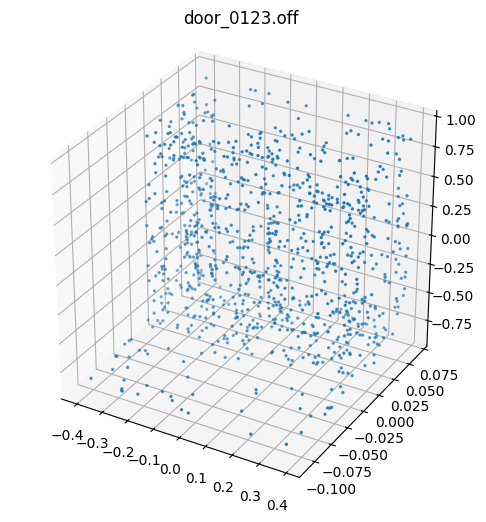

In [39]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=2)
ax.set_title(sample_file.name)
ax.set_box_aspect((1, 1, 1))
plt.show()

In [40]:
def augmentation(point_cloud):
    "Training augmentation from PointNet."
    angle = torch.empty(()).uniform_(0, 2 * torch.pi).item()
    cosval, sinval = torch.cos(torch.tensor(angle)).item(), torch.sin(torch.tensor(angle)).item()
    rotation = point_cloud.new_tensor([[cosval, 0.0, sinval], [0.0, 1.0, 0.0], [-sinval, 0.0, cosval]])
    jitter = (torch.randn_like(point_cloud) * 0.01).clamp(-0.05, 0.05)
    return point_cloud @ rotation + jitter

In [41]:
class ModelNetDataset(Dataset):
    "Dataset containing ModelNet point clouds."
    def __init__(self, samples, augment=False):
        self.samples = samples
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label_idx = self.samples[idx]
        point_cloud = load_modelnet_file(file_path)
        if self.augment:
            point_cloud = augmentation(point_cloud)
        label = torch.tensor(label_idx, dtype=torch.long)
        return point_cloud, label

# architecture

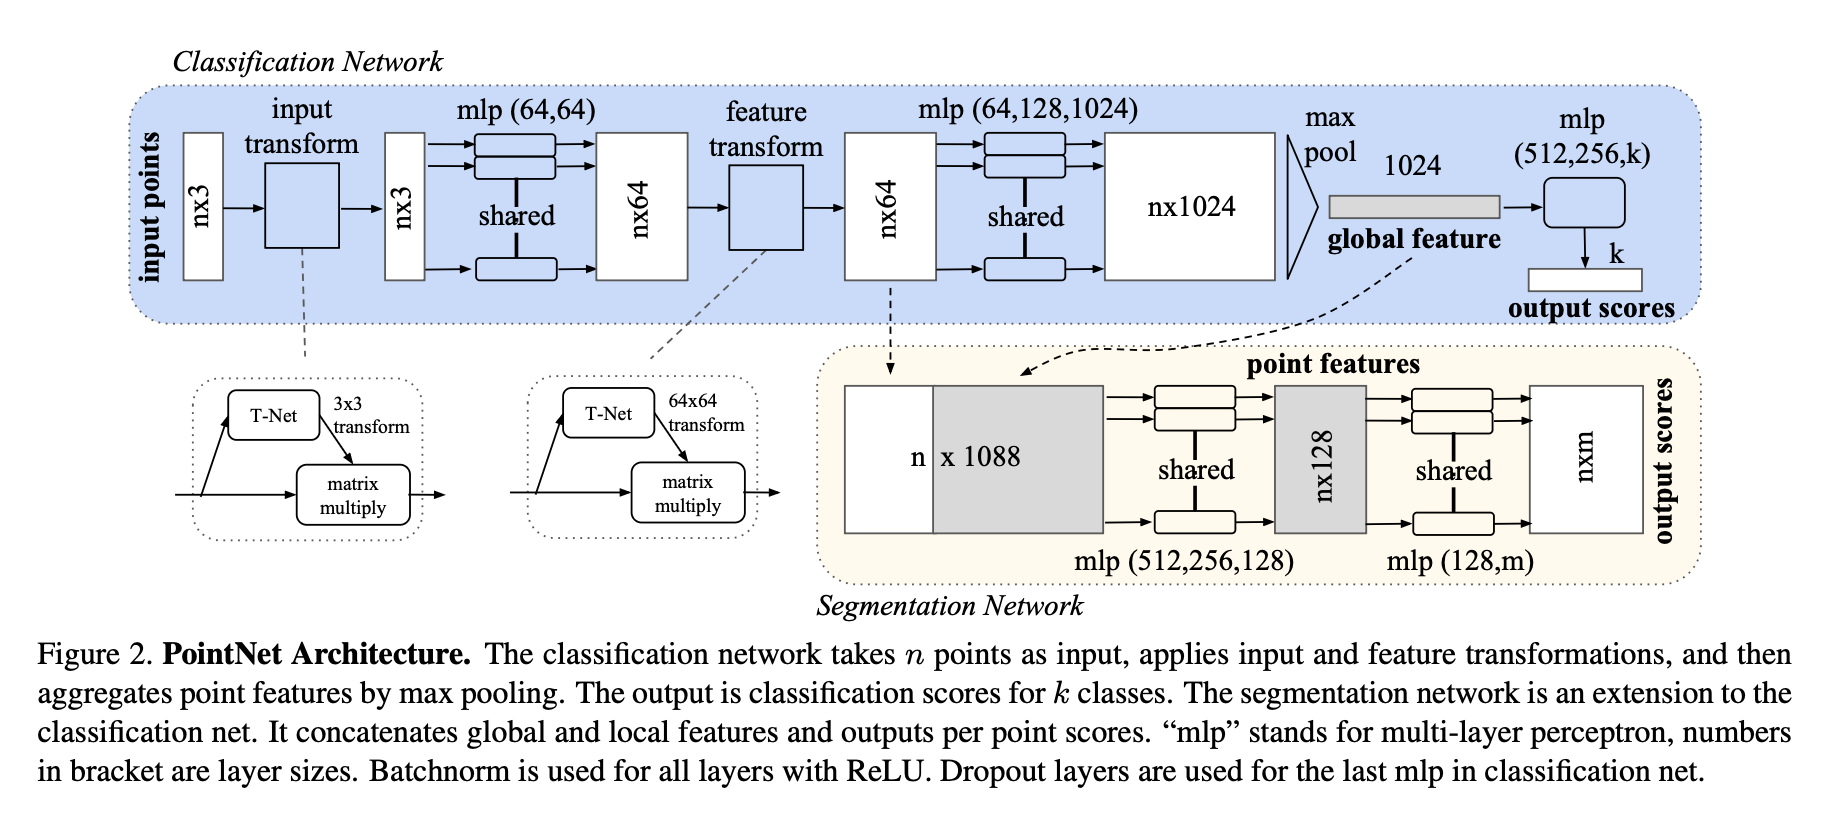

In [42]:
def xavier_init(module):
    "Helper to initialize weights with Xavier uniform, ignoring biaises and scalars."
    for p in module.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

In [43]:
class TNet(nn.Module):
    """Layer inside the transform layers. Outputs a D*D matrix to multiply the input.``
    This is meant to rotate+scale the points to make it size/rotation invariant.
    Invertible matrix with the loss penalties.
    """
    def __init__(self, feature_count):
        super().__init__()
        self.feature_count = feature_count
        self.ff1 = nn.Linear(feature_count, 64)
        self.norm1 = PointBatchNorm(64)
        self.ff2 = nn.Linear(64, 128)
        self.norm2 = PointBatchNorm(128)
        self.ff3 = nn.Linear(128, 1024)
        self.norm3 = PointBatchNorm(1024)
        self.ff4 = nn.Linear(1024, 512)
        self.norm4 = PointBatchNorm(512)
        self.ff5 = nn.Linear(512, 256)
        self.norm5 = PointBatchNorm(256)
        self.ff6 = nn.Linear(256, feature_count * feature_count)
        xavier_init(self)
        nn.init.zeros_(self.ff6.weight)
        nn.init.zeros_(self.ff6.bias)

    def forward(self, x):
        # x : (B, N, D)
        batch_size, _, _ = x.shape
        x = F.relu(self.norm1(self.ff1(x)))
        x = F.relu(self.norm2(self.ff2(x)))
        x = F.relu(self.norm3(self.ff3(x)))
        x = torch.max(x, dim=1)[0] # max-reduction over N
        x = F.relu(self.norm4(self.ff4(x)))
        x = F.relu(self.norm5(self.ff5(x)))
        x = self.ff6(x)  # last layer isn't normalized nor activated
        mat = x.view(batch_size, self.feature_count, self.feature_count) # (B, D, D)
        eye = torch.eye(self.feature_count, device=x.device).unsqueeze(0).repeat(batch_size, 1, 1)
        # identity matrices, shape: (B, D, D)
        return mat + eye

In [44]:
class PointBatchNorm(nn.Module):
    "BatchNorm with one channel per feature; stats are over batch and points."
    def __init__(self, feature_count):
        super().__init__()
        self.norm = nn.BatchNorm1d(feature_count)

    def forward(self, x):
        if x.dim() == 2:
            return self.norm(x)

        batch_size, point_count, feature_count = x.shape
        x = x.reshape(batch_size * point_count, feature_count)
        x = self.norm(x)
        return x.view(batch_size, point_count, feature_count)

In [45]:
class EncoderBlock(nn.Module):
    """Block of the main architecture contaning a TNet tranformed
    followed by a shared mlp (a size 1 kernel convolution).
    The shared property make it oblivious to point position in the sequence"""

    def __init__(self, input_feature, mlp_dims):
        super().__init__()
        self.tnet = TNet(feature_count=input_feature)
        self.mlp_layers = nn.ModuleList()
        self.mlp_norms = nn.ModuleList()
        for in_dim, out_dim in zip(mlp_dims[:-1], mlp_dims[1:]):
            self.mlp_layers.append(nn.Linear(in_dim, out_dim))
            self.mlp_norms.append(PointBatchNorm(out_dim))
 
    def forward(self, x):
        # x: (B, N, D)
        self.trans_matrix = self.tnet(x) # (B, D, D)
        x = x @ self.trans_matrix # transform layer mutiplying the input by TNet matrix

        for linear, norm in zip(self.mlp_layers[:-1], self.mlp_norms[:-1]):
            x = F.relu(norm(linear(x)))
        return self.mlp_norms[-1](self.mlp_layers[-1](x)) # last linear not followed by ReLU

In [46]:
class Generator(nn.Module):
    "Compute logits from the global features."
    def __init__(self, class_amount, dropout_rate):
        super().__init__()
        self.ff1 = nn.Linear(1024, 512, bias=False)
        self.norm1 = PointBatchNorm(512)
        self.ff2 = nn.Linear(512, 256, bias=False)
        self.norm2 = PointBatchNorm(256)
        self.ff3 = nn.Linear(256, class_amount)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        # x: (B, 1024)
        x = F.relu(self.norm1(self.ff1(x)))
        x = self.dropout(x)
        x = F.relu(self.norm2(self.ff2(x)))
        x = self.dropout(x)
        return self.ff3(x)

In [47]:
class PointNet(nn.Module):
    "The whole architecture"
    def __init__(self, feature_count):
        super().__init__()
        self.block1 = EncoderBlock(feature_count, [feature_count, 64, 64])
        self.block2 = EncoderBlock(64, [64, 64, 128, 1024])
        self.generator = Generator(len(MODELNET_CLASS_NAMES), CONFIG['dropout_rate'])

    def forward(self, x):
        # x: (B, N, D)
        batch_size, _, _ = x.shape
        x = self.block1(x) # x: (B, N, 64)
        x = self.block2(x) # x: (B, N, 1024)
        x = torch.max(x, dim=1)[0]  # maxpool over N
        x = x.view(batch_size, 1024)
        logits = self.generator(x)
        return logits

In [48]:
train_samples, valid_samples = validation_split(SEEDS[0])
test_samples = build_sample_index('test')
print(f'Train samples: {len(train_samples)}')
print(f'Validation samples: {len(valid_samples)}')
print(f'Test samples: {len(test_samples)}')

Train samples: 3945
Validation samples: 966
Test samples: 2468


In [49]:
# sanity check
model = PointNet(len(CONFIG["feature_names"]))

train_dataset = ModelNetDataset(train_samples, augment=True)
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
sample_batch, sample_labels = next(iter(train_loader))
output = model(sample_batch)

print(f'Input shape: {sample_batch.shape}')
print(f'Label shape: {sample_labels.shape}')
print(f'Output shape: {output.shape}')

Input shape: torch.Size([64, 1024, 3])
Label shape: torch.Size([64])
Output shape: torch.Size([64, 40])


# training

In [50]:
def create_dataloaders(batch_size, seed):
    "Create train and validation dataloaders."
    train_samples, valid_samples = validation_split(seed)
    train_dataset = ModelNetDataset(train_samples, augment=True)
    valid_dataset = ModelNetDataset(valid_samples)
    generator = torch.Generator().manual_seed(seed)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, generator=generator)
    valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
    return train_dataloader, valid_dataloader

In [51]:
def rate(sample_count, base):
    "Every 200k samples, the LR is multiplied by 0.7"
    decay_count = sample_count // CONFIG["lr_decay_samples"]
    return max(base * CONFIG["lr_decay_gamma"] ** decay_count, CONFIG["min_lr"])

In [52]:
def smoothing(pred, targets, smoothing=0):
    "The true class becomes 1-smoothing, and the rest of the probability is distributed amongst the other classes"
    targets = targets.contiguous().view(-1)
    class_amount = pred.size(1)
    one_hot = torch.zeros_like(pred).scatter(1, targets.view(-1, 1), 1)
    one_hot = one_hot * (1 - smoothing) + (1 - one_hot) * smoothing / (class_amount - 1)
    log_prob = F.log_softmax(pred, dim=1)
    return -(one_hot * log_prob).sum(dim=1).mean()

In [53]:
def orthogonal(matrix):
    "Penalty term to make the TNet matrices more orthogonal."
    batch_size, feature_count, _ = matrix.shape # matrix: (B, D, D)
    eye = torch.eye(feature_count, device=matrix.device).unsqueeze(0).repeat(batch_size, 1, 1)
    diff = eye - matrix@matrix.transpose(-1,-2)
    return diff.pow(2).sum(dim=(-1, -2)).mean()

In [54]:
class Loss:
    "Cross-entropy loss with smoothing. Regulation on the TNet matrices to make them orthogonal."
    def __init__(self, model, regul_coeff = 0.001):
        self.model = model
        self.regul_coeff = regul_coeff

    def __call__(self, out, targets, batch_size):
        loss_node = smoothing(out, targets, CONFIG['smoothing'])
        reg = orthogonal(self.model.block2.trans_matrix)
        loss_node = loss_node + self.regul_coeff * reg
        loss = loss_node.detach() * batch_size
        return loss, loss_node

In [55]:
def run_epoch(data_iter, model, loss_compute, optimizer=None, mode="train", seen_samples=0):
    "Runs one epoch, either for training, either validation."
    start, device = time.time(), torch.device(DEVICE)
    total_tokens, total_loss, tokens = 0, 0, 0
    loss_list, grad_norms, logit_maxes, weight_maxes = [], [], [], []
    for i, (src, targets) in enumerate(data_iter):
        src, targets = src.to(device), targets.to(device)
        ntokens = targets.size(0)
        logits = model.forward(src)
        loss, loss_node = loss_compute(logits, targets, ntokens)

        if mode == "train":
            for param_group in optimizer.param_groups: param_group["lr"] = rate(seen_samples, CONFIG["base_lr"])
            loss_node.backward()
            if optimizer is not None:
                norm = torch.nn.utils.clip_grad_norm_(model.parameters(), float("inf")).item()
                grad_norms.append(norm)
                optimizer.step(); optimizer.zero_grad(set_to_none=True)
                logit_maxes.append(logits.detach().abs().max().item())
                weight_maxes.append(torch.stack([parameter.detach().abs().max() for name, parameter in model.named_parameters() if name.endswith("weight")]).max().item())
            seen_samples += ntokens
        total_loss += loss; total_tokens += ntokens; tokens += ntokens
        loss_list.append((loss / ntokens).item())
        if mode == "train":
            lr, elapsed = optimizer.param_groups[0]["lr"], time.time() - start
            print(f"Batch: {i:6d} | Loss: {loss / ntokens:6.2f} | Samples/sec: {tokens / elapsed:7.1f} | Learn. Rate: {lr:6.1e}")
            start, tokens = time.time(), 0

    return loss_list, grad_norms, logit_maxes, weight_maxes, seen_samples

In [ ]:
def plot(train_losses, valid_losses, all_grad_norms, all_logit_maxes, all_weight_maxes, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means):
    "Plot losses, gradient norms, maximum logits, and maximum weights."
    x_train = [e + i / s for e, s in enumerate(train_epoch_sizes) for i in range(s)]
    x_valid = [e + i / s for e, s in enumerate(valid_epoch_sizes) for i in range(s)]
    epoch_mean_valid_losses = [m for s, m in zip(valid_epoch_sizes, epoch_means) for _ in range(s)]
    tick_step = max(1, (num_epochs + 19) // 20)
    epoch_ticks = list(range(0, num_epochs + 1, tick_step))
    if epoch_ticks[-1] != num_epochs: epoch_ticks.append(num_epochs)
    plt.figure(figsize=(10, 20))
    ax1 = plt.subplot(4, 1, 1)
    w = max(1, int((len(train_losses) / num_epochs) * 0.1))
    train_loss_rolling = pd.Series(train_losses).rolling(window=w, center=True).mean()
    plt.plot(x_train, train_losses, label="Training Loss"); plt.plot(x_train, train_loss_rolling, label="Training Loss (Avg)", color="darkblue", linewidth=1); plt.plot(x_valid, valid_losses, label="Validation Loss", alpha=0.7); plt.plot(x_valid, epoch_mean_valid_losses, label="Val Loss (Avg)", color="red", linewidth=1, linestyle="--")
    plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Training and Validation Loss per batch")
    ax1.set_xlim(0, num_epochs); ax1.set_xticks(epoch_ticks)
    loss_values = pd.Series(train_losses + valid_losses + epoch_means).dropna()
    q1, q3 = loss_values.quantile(0.25), loss_values.quantile(0.75)
    bottom, top = max(0, q1 - 1.5 * (q3 - q1)), q3 + 1.5 * (q3 - q1)
    if top < loss_values.max(): ax1.set_ylim(bottom, top + max((top - bottom) * 0.05, 1e-6))
    y_min, y_max = ax1.get_ylim()
    best_mean_val = float("inf")
    for i, mean_val in enumerate(epoch_means):
        if mean_val <= best_mean_val and y_min <= mean_val <= y_max: ax1.text(i + 0.5, mean_val, f"{mean_val:.3g}", color="red", ha="center", va="bottom", fontweight="medium", clip_on=True)
        best_mean_val = min(best_mean_val, mean_val)
    ax = plt.subplot(4, 1, 2)
    plt.plot(x_train, all_grad_norms, label="Gradient Norm", color="orange"); plt.xlabel("Epochs"); plt.ylabel("Norm"); plt.legend(); plt.title("Gradient Norm per batch")
    ax.set_xlim(0, num_epochs); ax.set_xticks(epoch_ticks)
    grad_values = pd.Series(all_grad_norms).dropna()
    q1, q3 = grad_values.quantile(0.25), grad_values.quantile(0.75)
    central_grad_values = grad_values[grad_values <= q3 + 1.5 * (q3 - q1)]
    grad_threshold = central_grad_values.mean() + 25 * central_grad_values.var()
    visible_grad_values = grad_values[grad_values <= grad_threshold]
    bottom, top = visible_grad_values.min(), visible_grad_values.max()
    margin = max((top - bottom) * 0.05, 1e-6)
    ax.set_ylim(max(0, bottom - margin), top + margin)
    ax.text(0.99, 0.02, f"Params count: {model_param_count:,}", transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="dimgray")
    ax = plt.subplot(4, 1, 3)
    plt.plot(x_train, all_logit_maxes, label="Max |Logit|", color="purple"); plt.xlabel("Epochs"); plt.ylabel("Max |Logit|"); plt.legend(); plt.title("Maximum Absolute Final-Head Logit per Batch")
    ax.set_xlim(0, num_epochs); ax.set_xticks(epoch_ticks)
    ax = plt.subplot(4, 1, 4)
    plt.plot(x_train, all_weight_maxes, label="Max |Weight|", color="green"); plt.xlabel("Epochs"); plt.ylabel("Max |Weight|"); plt.legend(); plt.title("Maximum Absolute Model Weight per Batch")
    ax.set_xlim(0, num_epochs); ax.set_xticks(epoch_ticks)
    plt.subplots_adjust(hspace=0.35); plt.show()

In [57]:
def train_model(seed, num_epochs):
    "Training process of the model, over all the epochs."
    torch.manual_seed(seed)
    load_modelnet_file.cache_clear()
    print(f"Training process starting for seed {seed}...", flush=True)
    model = PointNet(len(CONFIG["feature_names"])).to(torch.device(DEVICE))
    model_param_count = sum(p.numel() for p in model.parameters())
    train_dataloader, valid_dataloader = create_dataloaders(CONFIG["batch_size"], seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=rate(0, CONFIG["base_lr"]), betas=(CONFIG["adam_momentum"], 0.999))
    train_losses, valid_losses, all_grad_norms, all_logit_maxes, all_weight_maxes = [], [], [], [], []
    train_epoch_sizes, valid_epoch_sizes, epoch_means = [], [], []
    seen_samples = 0
    loss_compute, checkpoint_dir = Loss(model), CHECKPOINT_ROOT / f"seed_{seed}"
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(num_epochs):
        model.train(); print(f"Epoch n°{epoch} Training ====", flush=True)
        loss_list, grad_norms, logit_maxes, weight_maxes, seen_samples = run_epoch(train_dataloader, model, loss_compute, optimizer, mode="train", seen_samples=seen_samples)
        train_losses.extend(loss_list); train_epoch_sizes.append(len(loss_list)); all_grad_norms.extend(grad_norms); all_logit_maxes.extend(logit_maxes); all_weight_maxes.extend(weight_maxes)
        torch.save(model.state_dict(), checkpoint_dir / f"checkpoint_{epoch:02d}.pt")
        clear_output(wait=True)
        print(f"Training process starting for seed {seed}...", flush=True)
        if len(valid_dataloader) > 0:
            print(f"Epoch n°{epoch} Validation ====", flush=True); model.eval()
            with torch.no_grad():
                loss_list, _, _, _, _ = run_epoch(valid_dataloader, model, loss_compute, None, mode="eval")
            valid_losses.extend(loss_list); valid_epoch_sizes.append(len(loss_list))
            mean_val = sum(loss_list) / len(loss_list); epoch_means.append(mean_val)
            print(f"Epoch n°{epoch} complete | Validation loss: {mean_val:.4f}", flush=True)
        plot(train_losses, valid_losses, all_grad_norms, all_logit_maxes, all_weight_maxes, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means)

Training process starting for seed 12...
Epoch n°99 Validation ====
Epoch n°99 complete | Validation loss: 1.4407


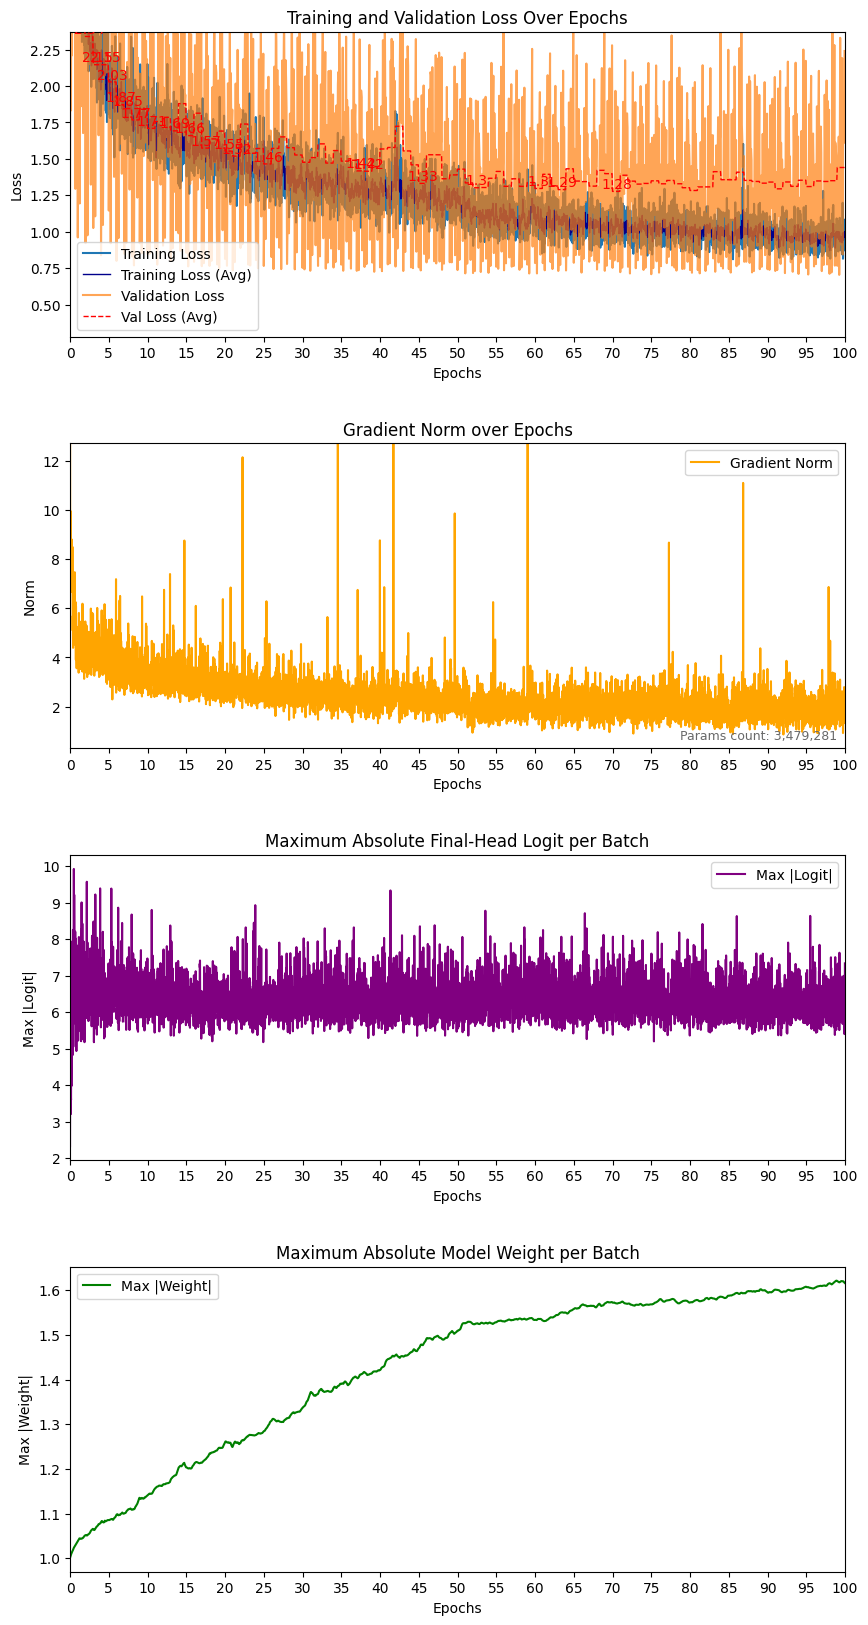

In [58]:
if __name__ == "__main__":
    for seed in SEEDS:
        train_model(seed, CONFIG['num_epochs'])

# inference/evalutation

In [59]:
def compute_f1(predictions, labels):
    "Compute the macro F1 score."
    scores = []
    for class_idx in range(len(MODELNET_CLASS_NAMES)):
        true_positive = ((predictions == class_idx) & (labels == class_idx)).sum().item()
        false_positive = ((predictions == class_idx) & (labels != class_idx)).sum().item()
        false_negative = ((predictions != class_idx) & (labels == class_idx)).sum().item()
        denominator = 2 * true_positive + false_positive + false_negative
        scores.append(0.0 if denominator == 0 else 2 * true_positive / denominator)
    return torch.tensor(scores, dtype=torch.float32)

In [60]:
def evaluate_validation(epoch, seed):
    "Score a checkpoint on validation set for accuracy and F1."
    checkpoint_path = CHECKPOINT_ROOT / f"seed_{seed}" / f"checkpoint_{epoch:02d}.pt"
    device = torch.device(DEVICE)
    model = PointNet(len(CONFIG['feature_names'])).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device)); model.eval()
    eval_loader = DataLoader(ModelNetDataset(validation_split(seed)[1]), batch_size=CONFIG['batch_size'], shuffle=False)

    predictions, true_labels = [], []
    with torch.no_grad():
        for batch, labels in eval_loader:
            predictions.append(model(batch.to(device)).argmax(dim=1).cpu())
            true_labels.append(labels.cpu())

    predictions, labels = torch.cat(predictions), torch.cat(true_labels)
    per_class_f1 = compute_f1(predictions, labels)
    accuracy = (predictions == labels).float().mean().item()
    per_class_scores = {name: float(score) for name, score in zip(MODELNET_CLASS_NAMES, per_class_f1)}
    return per_class_f1.mean().item(), per_class_scores, accuracy

In [61]:
def plot_validation_metrics(seed):
    "Plot validation accuracy and F1 for every checkpoint."
    torch.manual_seed(seed); load_modelnet_file.cache_clear()
    checkpoint_id = lambda path: int(path.stem.split("_")[-1])
    checkpoint_paths = sorted((CHECKPOINT_ROOT / f"seed_{seed}").glob("checkpoint_*.pt"), key=checkpoint_id)
    if len(validation_split(seed)[1]) == 0: return None

    checkpoint_numbers = [checkpoint_id(path) for path in checkpoint_paths]
    metrics = [evaluate_validation(checkpoint, seed) for checkpoint in checkpoint_numbers]
    macro_f1_scores, accuracy_scores = ([metric[i] for metric in metrics] for i in (0, 2))

    fig, ax = plt.subplots(figsize=(10, 5))
    lines = [ax.plot(checkpoint_numbers, scores, marker="o", label=label)[0] for scores, label in ((macro_f1_scores, "Macro F1"), (accuracy_scores, "Accuracy"))]
    for scores, line, offset in zip((macro_f1_scores, accuracy_scores), lines, (0.02, 0.05)):
        best = -1
        for checkpoint, score in zip(checkpoint_numbers, scores):
            if score > best:
                ax.text(checkpoint, score + offset, f"{score:.3f}", ha="center", color=line.get_color())
                best = score

    tick_step = 1 if len(checkpoint_paths) <= 20 else max(2, (len(checkpoint_paths) + 14) // 15)
    tick_indices = list(range(0, len(checkpoint_paths), tick_step))
    ax.set_xticks([checkpoint_numbers[i] for i in tick_indices],
                  [checkpoint_paths[i].stem for i in tick_indices], rotation=45, ha="right")
    ax.set_xlim(checkpoint_numbers[0] - 0.5, checkpoint_numbers[-1] + 0.5)
    ax.set_ylim(min(macro_f1_scores + accuracy_scores) - 0.02, 1)
    ax.set(xlabel="Checkpoint", ylabel="Score", title="Validation checkpoint performance")
    ax.legend(); fig.tight_layout(); plt.show()
    best_checkpoint = checkpoint_numbers[accuracy_scores.index(max(accuracy_scores))]
    print(f'Seed {seed} best accuracy checkpoint: {best_checkpoint}')
    return best_checkpoint

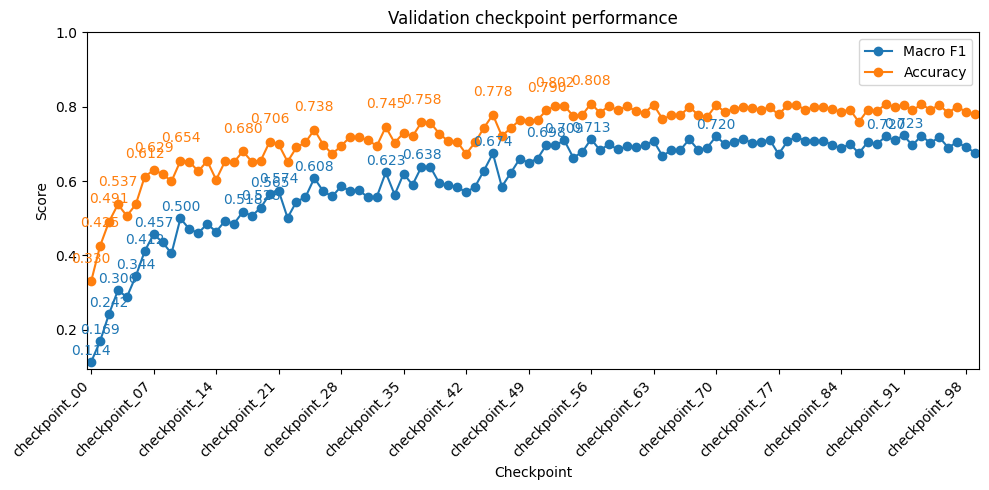

Seed 12 best accuracy checkpoint: 56


In [62]:
best_by_seed = {seed: plot_validation_metrics(seed) for seed in SEEDS}

In [63]:
def evaluate_test(epoch, seed):
    "Evaluate a checkpoint epoch on test."
    torch.manual_seed(seed); load_modelnet_file.cache_clear()
    checkpoint_path, device = CHECKPOINT_ROOT / f"seed_{seed}" / f"checkpoint_{epoch:02d}.pt", torch.device(DEVICE)
    model = PointNet(len(CONFIG['feature_names'])).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device)); model.eval()

    eval_loader = DataLoader(
        ModelNetDataset(build_sample_index('test')), batch_size=CONFIG['batch_size'], shuffle=False)

    predictions, true_labels = [], []
    with torch.no_grad():
        for batch, labels in eval_loader:
            predictions.append(model(batch.to(device)).argmax(dim=1).cpu())
            true_labels.append(labels.cpu())

    predictions, labels = torch.cat(predictions), torch.cat(true_labels)
    per_class_f1 = compute_f1(predictions, labels)
    per_class_scores = {name: float(score) for name, score in zip(MODELNET_CLASS_NAMES, per_class_f1)}
    test_macro_f1, test_accuracy = per_class_f1.mean().item(), (predictions == labels).float().mean().item()
    print(f'Seed {seed} | Test macro F1: {test_macro_f1:.4f}\nSeed {seed} | Test accuracy: {test_accuracy:.4f}')
    #print(per_class_scores)
    return test_accuracy

In [64]:
best_test_scores = {seed: evaluate_test(best_by_seed[seed], seed) for seed in SEEDS}
#last_test_scores = {seed: evaluate_test(CONFIG['num_epochs'] - 1, seed) for seed in SEEDS}
print('Best checkpoint test scores:', best_test_scores)
#print('Last checkpoint test scores:', last_test_scores)

Seed 12 | Test macro F1: 0.6928
Seed 12 | Test accuracy: 0.7776
Best checkpoint test scores: {12: 0.7775526642799377}
